# GUV Image Analysis Pipeline

This notebook contains a pipeline for analyzing GUV (Giant Unilamellar Vesicle) images. It processes both single-frame and time-trace data from .tif files.

In [1]:
import csv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# Import custom modules
import vesicles as vs

# set up autoreload on all files
%load_ext autoreload
%autoreload 2

### GUV Class Definition
class GUV:
    def __init__(self):
        self.exp_id = 0
        self.label = 'any_label'
        self.comment = []
        self.use_it = []
        self.crop_it = []
        self.dt = 1

## Helper Functions

### `get_data_selections(run_id)`

This function reads GUV data from an Excel file and returns a list of GUV objects for a specific run ID.
We define a `GUV` class to store properties of a single GUV movie.

In [2]:
def get_data_selections(run_id,filename):
    wb = load_workbook(filename)
    sheet_files = wb['guvs']
    
    # Create a dictionary of column names
    Header = {COL[0].value: idx for idx, COL in enumerate(sheet_files.iter_cols(1, sheet_files.max_column))}
    
    Guv_list = []
    for row_cells in sheet_files.iter_rows(min_row=2, max_row=sheet_files.max_row):
        Guv = GUV()
        Guv.exp_id = row_cells[Header["exp_id"]].value
        Guv.movie_id = row_cells[Header["movie_id"]].value
        Guv.label = row_cells[Header["guv_label"]].value
        Guv.use_it = row_cells[Header["use"]].value
        Guv.crop_it = row_cells[Header["crop"]].value
        Guv.dt = row_cells[Header["dt(s)"]].value
        if Guv.exp_id == run_id:
            Guv_list.append(Guv)
    return Guv_list

## Main Analysis Pipeline

The main analysis is divided in a few main steps. For historical reasons, these are labeled A00, A10 ...etc. These labels are also used for the organization of saved data (pictures, tables) so that one can backtrack this data to the generating code.

### A00: set up the experiment
Fetch the experiment parameters: these are listed in 'A00_init and include paths, movienames etc.'. An experiment has a unique index. This 'movie-id' index is for example used as a look-up in a user-excel (see cell below, multi-tiffs). Since I keep some local copies, I added a decimal to this index to tell the code where to look (local or remote). The 'A00_init' file also serves as a config file: it allows you to choose where to find data and where to save these.
In the current run, we use data from '20082025_CS_test' as experiment '0'
All associated output, such as intermediate plots and data, can then be found under: M:\tnw\bn\cd\Shared\Jacob\TESTdata_out\2025_Charu\pilots\20082025_CS_test and in the subdirectories there

In [3]:
from vesicles import A00_init
expi = 0.2  
    # 0.2: Charu's test data, C=1, decimal .2 refers to remote drive
    # 1.2: Charu's test data, C=2, decimal .2 refers to remote drive
movie_to_use_list = [0]  #should be identical to 'movie-id' list in user-excel (see below)
movie_simbol_list = ['r']

initval = A00_init.get_exps(expi)


### A10: Cropping
With cropping, we cut out indivdidual vesicles from the stack and save them to individual tiff files. We do this because this eases the follow-up analysis: each stack is assumed to contain only one full vesicle in the center, with approximately a constant coverage of the middle area of the ROI.
This step requires the user to perform (easy) pre-selection in Fiji or ImageJ. Please read the README.txt for detailed info how to do that. In the output directory, a sub-dir names '\A100_overviews' shows all selected vesicles, annotated by their index. This index is used downstream as a unique vesicle-ID. In additon, a sub-direcry 'A10_rois' collects tiff files or ROIs cut around the vesicles. Each ROI-tiff contains all Z-palnes with just this vesicle n the center (all neighbouring vesicles will be suppressed in the downstream analysis)

C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_io.py:417: RuntimeWarning: divide by zero encountered in log
  ovv_im=np.log(chan)


a10:from_tiff_01_roi0_c0.tif
a10:from_tiff_01_roi1_c0.tif
a10:from_tiff_01_roi2_c0.tif
a10:from_tiff_01_roi3_c0.tif
a10:from_tiff_01_roi4_c0.tif
a10:from_tiff_01_roi5_c0.tif
a10:from_tiff_01_roi6_c0.tif
a10:from_tiff_01_roi7_c0.tif
a10:from_tiff_01_roi8_c0.tif
a10:from_tiff_01_roi9_c0.tif
a10:from_tiff_01_roi10_c0.tif
a10:from_tiff_01_roi11_c0.tif
a10:from_tiff_01_roi12_c0.tif
a10:from_tiff_01_roi13_c0.tif
a10:from_tiff_01_roi14_c0.tif
a10:from_tiff_01_roi15_c0.tif
a10:from_tiff_01_roi16_c0.tif
a10:from_tiff_01_roi17_c0.tif
a10:from_tiff_01_roi18_c0.tif
a10:from_tiff_01_roi19_c0.tif
a10:from_tiff_01_roi20_c0.tif
a10:from_tiff_01_roi21_c0.tif
a10:from_tiff_01_roi22_c0.tif
a10:from_tiff_01_roi23_c0.tif
a10:from_tiff_01_roi24_c0.tif
a10:from_tiff_01_roi25_c0.tif
a10:from_tiff_01_roi26_c0.tif
a10:from_tiff_01_roi27_c0.tif
a10:from_tiff_01_roi28_c0.tif
a10:from_tiff_01_roi29_c0.tif
a10:from_tiff_01_roi30_c0.tif
a10:from_tiff_01_roi31_c0.tif
a10:from_tiff_01_roi32_c0.tif
a10:from_tiff_01_roi

C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_io.py:445: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_io.py:417: RuntimeWarning: divide by zero encountered in log
  ovv_im=np.log(chan)


a10:from_tiff_00_roi0_c0.tif
a10:from_tiff_00_roi1_c0.tif
a10:from_tiff_00_roi2_c0.tif
a10:from_tiff_00_roi3_c0.tif
a10:from_tiff_00_roi4_c0.tif
a10:from_tiff_00_roi5_c0.tif
a10:from_tiff_00_roi6_c0.tif
a10:from_tiff_00_roi7_c0.tif
a10:from_tiff_00_roi8_c0.tif
a10:from_tiff_00_roi9_c0.tif
a10:from_tiff_00_roi10_c0.tif
a10:from_tiff_00_roi11_c0.tif
a10:from_tiff_00_roi12_c0.tif
a10:from_tiff_00_roi13_c0.tif
a10:from_tiff_00_roi14_c0.tif
a10:from_tiff_00_roi15_c0.tif
a10:from_tiff_00_roi16_c0.tif
a10:from_tiff_00_roi17_c0.tif
a10:from_tiff_00_roi18_c0.tif
a10:from_tiff_00_roi19_c0.tif
a10:from_tiff_00_roi20_c0.tif
a10:from_tiff_00_roi21_c0.tif
a10:from_tiff_00_roi22_c0.tif
a10:from_tiff_00_roi23_c0.tif
a10:from_tiff_00_roi24_c0.tif
a10:from_tiff_00_roi25_c0.tif
a10:from_tiff_00_roi26_c0.tif
a10:from_tiff_00_roi27_c0.tif
a10:from_tiff_00_roi28_c0.tif
a10:from_tiff_00_roi29_c0.tif
a10:from_tiff_00_roi30_c0.tif
a10:from_tiff_00_roi31_c0.tif
a10:from_tiff_00_roi32_c0.tif
a10:from_tiff_00_roi

C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_io.py:445: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


KeyboardInterrupt: 

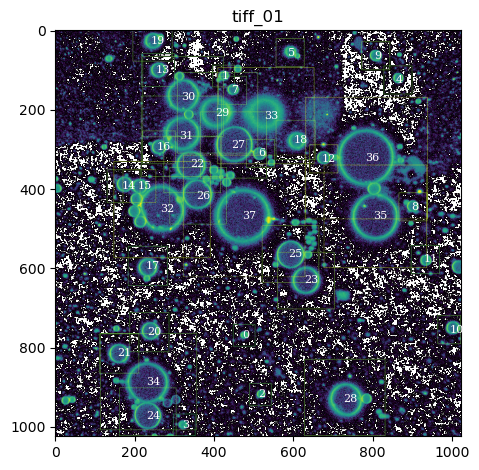

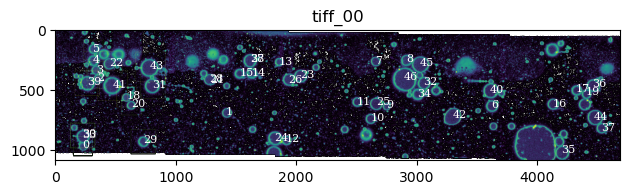

In [4]:
from vesicles import A10_muscope_crop
A10_muscope_crop.main(initval)

## A20: First processing of regions-of-interest (ROIs)
In this step, we first (in 'A20a') isolate the area of the vesicle to obtain masks, but also some general geometry features such as radius, area and other shape characteristics. Next (in 'A20b'), we perfom detailed analysis of every color channel. Data is saved in xarray format and saved to a .nc file. For this data, parameters share at least one common axis, which is just the vesicle index. Below an overview of the data is shown. At this stage, we still analyze all Z-planes, so lots of the data is in a 2-dimensional [vesicle-index, plane] format. Various inspection plots can be found in the subdir 'A20b_processed', showing how well the masking worked, if the data-per plane is regular etc. For example, the area vs. plane graph should show a smooth maximum on the plane associated with the equatorial plane.

In [5]:
from vesicles import A20_process_rois

A20_process_rois.main(initval,1,1)

a20a:file_tiff_01_roi0c0frame0
bad14
bad15


C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_process_stacks.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


a20a:file_tiff_01_roi1c0frame0
a20a:file_tiff_01_roi2c0frame0
bad14
bad15
a20a:file_tiff_01_roi3c0frame0
bad14
bad15
a20a:file_tiff_01_roi4c0frame0
a20a:file_tiff_01_roi5c0frame0
a20a:file_tiff_01_roi6c0frame0
a20a:file_tiff_01_roi7c0frame0
a20a:file_tiff_01_roi8c0frame0
a20a:file_tiff_01_roi9c0frame0
a20a:file_tiff_01_roi10c0frame0
a20a:file_tiff_01_roi11c0frame0
a20a:file_tiff_01_roi12c0frame0
a20a:file_tiff_01_roi13c0frame0
a20a:file_tiff_01_roi14c0frame0
a20a:file_tiff_01_roi15c0frame0
a20a:file_tiff_01_roi16c0frame0
a20a:file_tiff_01_roi17c0frame0
a20a:file_tiff_01_roi18c0frame0
a20a:file_tiff_01_roi19c0frame0
a20a:file_tiff_01_roi20c0frame0
a20a:file_tiff_01_roi21c0frame0
a20a:file_tiff_01_roi22c0frame0
a20a:file_tiff_01_roi23c0frame0
a20a:file_tiff_01_roi24c0frame0
a20a:file_tiff_01_roi25c0frame0
a20a:file_tiff_01_roi26c0frame0
a20a:file_tiff_01_roi27c0frame0


C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_tools.py:509: RuntimeWarning: divide by zero encountered in log
  montage_tiff[loy:hiy,lox:hix]=np.log(abs(fov)+1)
C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_tools.py:510: RuntimeWarning: divide by zero encountered in log
  t=np.log(fov+1)


a20a:file_tiff_01_roi28c0frame0
a20a:file_tiff_01_roi29c0frame0


...

a20a:file_tiff_00_roi44c0frame0
a20a:file_tiff_00_roi45c0frame0
a20a:file_tiff_00_roi46c0frame0
<xarray.Dataset> Size: 54kB
Dimensions:    (index: 47, plane: 16)
Coordinates:
  * index      (index) int64 376B 0 1 2 3 4 5 6 7 8 ... 39 40 41 42 43 44 45 46
  * plane      (plane) int64 128B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
Data variables: (12/14)
    Area       (index, plane) float64 6kB 5.326e+03 5.233e+03 ... 2.621e+04
    Xg         (index, plane) float64 6kB 73.02 73.76 74.44 ... 197.5 196.3
    Yg         (index, plane) float64 6kB 80.09 79.74 80.86 ... 161.5 164.4
    R_minor    (index, plane) float64 6kB 42.67 42.04 43.71 ... 62.72 56.1 54.31
    R_major    (index, plane) float64 6kB 47.19 47.29 46.37 ... 182.6 182.7
    Perimeter  (index, plane) float64 6kB 370.4 372.7 ... 1.045e+03 1.044e+03
    ...         ...
    X0_cut     (index, plane) int32 3kB 232 232 232 232 ... 2902 2902 2902 2902
    Y0_cut     (index, plane) int32 3kB 969 969 969 969 969 ... 406 406 406 406
    R0

C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_tools.py:280: RuntimeWarning: divide by zero encountered in scalar divide
  angularstep=np.pi/2/spokesnoperquad #This is the step size of the angles


a20b:file_tiff_00_roi33c0frame0
a20b:file_tiff_00_roi34c0frame0
a20b:file_tiff_00_roi35c0frame0


C:\Users\jkerssemakers\AppData\Local\miniconda3\envs\min_analysis\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\jkerssemakers\AppData\Local\miniconda3\envs\min_analysis\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\jkerssemakers\AppData\Local\miniconda3\envs\min_analysis\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\jkerssemakers\AppData\Local\miniconda3\envs\min_analysis\Lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\jkerssemakers\AppData\Local\miniconda3\envs\min_analysis\Lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value e

a20b:file_tiff_00_roi36c0frame0
a20b:file_tiff_00_roi37c0frame0
a20b:file_tiff_00_roi38c0frame0
a20b:file_tiff_00_roi39c0frame0
a20b:file_tiff_00_roi40c0frame0
a20b:file_tiff_00_roi41c0frame0
a20b:file_tiff_00_roi42c0frame0
a20b:file_tiff_00_roi43c0frame0
a20b:file_tiff_00_roi44c0frame0
a20b:file_tiff_00_roi45c0frame0
a20b:file_tiff_00_roi46c0frame0
<xarray.Dataset> Size: 102kB
Dimensions:         (index: 47, plane: 16, channel: 1)
Coordinates:
  * index           (index) int64 376B 0 1 2 3 4 5 6 7 ... 40 41 42 43 44 45 46
  * plane           (plane) int64 128B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * channel         (channel) int64 8B 0
Data variables: (12/22)
    Inside_I        (index, plane, channel) float64 6kB 5.995 5.322 ... 4.104
    Outside_I       (index, plane, channel) float64 6kB 5.602 5.11 ... 10.83
    edge_I_mx       (index, plane, channel) float64 6kB 90.2 94.97 ... 1.305
    Edge_I_sum_msk  (index, plane, channel) float64 6kB 6.228e+04 ... 7.669e+04
    Edge_I_sum_po

### II. Multi-frame Data Processing and Visualization

For time-trace or z-plane .tif files, we process the data and create visualizations. Since these movies can have some time slots-of-interest, we load an extra excel table that allows a user to crop data of processed movies (or discard them at all). Note that the 'movie-I' field should match the above movie-IDs.

<bound method Dataset.info of <xarray.Dataset> Size: 75kB
Dimensions:         (index: 35, plane: 16, channel: 1)
Coordinates:
  * index           (index) int32 140B 0 1 2 3 4 5 6 7 ... 28 29 30 31 32 33 34
  * plane           (plane) int32 64B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * channel         (channel) int32 4B 0
Data variables: (12/21)
    Inside_I        (index, plane, channel) float64 4kB 6.31 4.703 ... 3.398
    Outside_I       (index, plane, channel) float64 4kB 8.125 7.362 ... 9.908
    edge_I_mx       (index, plane, channel) float64 4kB 42.39 58.59 ... 150.9
    Edge_I_sum_msk  (index, plane, channel) float64 4kB 8.907e+04 ... 8.634e+04
    Edge_I_sum_pol  (index, plane, channel) float64 4kB 850.3 ... 1.188e+03
    Edge_I_sum_std  (index, plane, channel) float64 4kB 0.9972 0.9613 ... 1.135
    ...              ...
    R_major         (index, plane) float64 4kB 73.98 72.37 73.8 ... 51.64 51.11
    Perimeter       (index, plane) float64 4kB 479.7 467.9 479.2 ... 332.3 329.

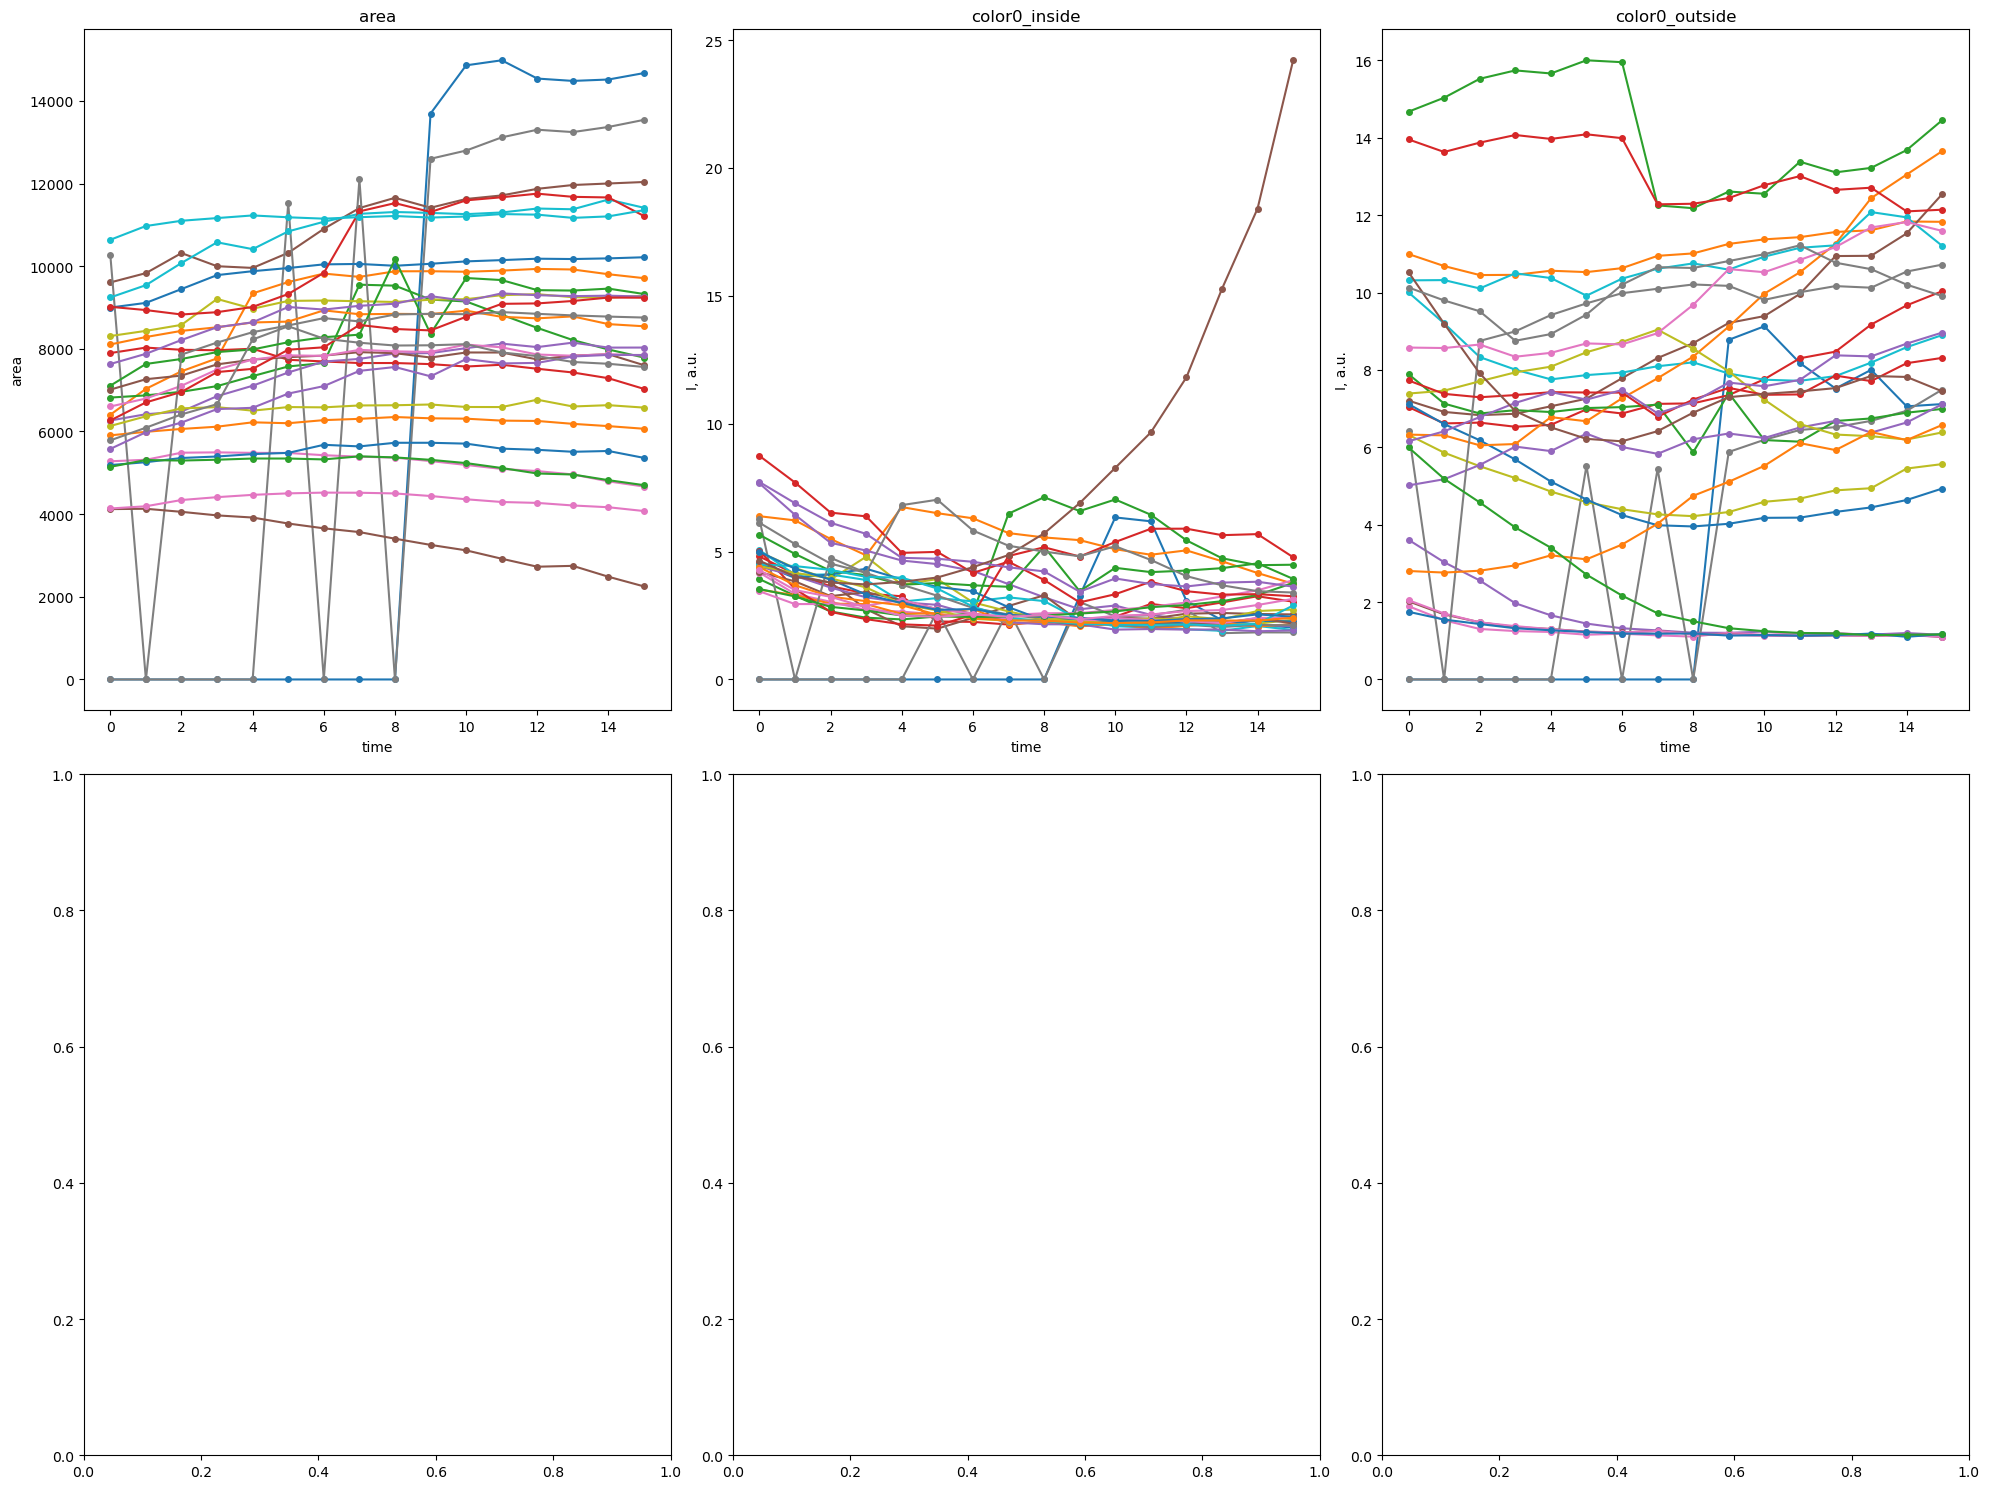

In [16]:
#import importlib
#importlib.reload(vesicles.common_tools)
from vesicles import A30_collect_processed_rois
from vesicles.common_tools import guv_io
selections_filename="data_overview_Charu.xlsx"
Guv_list = guv_io.get_data_selections(round(expi), selections_filename)

A30_collect_processed_rois.main(initval, Guv_list, movie_to_use_list)
plt.show()

This completes the GUV image analysis pipeline. The notebook processes both single-frame and time-trace .tif files, collecting data and creating visualizations for various GUV metrics.